In [174]:
import sys
import os
os.chdir('/zhome/71/c/146676/main/')
sys.path.append('/zhome/71/c/146676/main/')
import time
import SimpleITK as sitk
import numpy as np
from astropy.io import fits
from helpers import module_auxiliary as ma
import tifffile
import matplotlib.pyplot as plt
from helpers import extended_data as ed
from cil.recon import FBP
#from cil.plugins.astra import FBP
from cil.framework import AcquisitionGeometry, AcquisitionData, ImageGeometry, ImageData, BlockDataContainer
from cil.plugins.ccpi_regularisation.functions import FGP_TV
from cil.optimisation.functions import L2NormSquared, L1Norm, BlockFunction, MixedL21Norm, IndicatorBox, TotalVariation, LeastSquares
from cil.optimisation.operators import BlockOperator, GradientOperator, IdentityOperator, FiniteDifferenceOperator
from cil.optimisation.algorithms import CGLS, SIRT, GD, FISTA, ISTA, PDHG, SPDHG
from cil.plugins.astra.operators import ProjectionOperator
from cil.optimisation.functions import IndicatorBox, MixedL21Norm, L2NormSquared, \
                                       BlockFunction, L1Norm, LeastSquares, \
                                       OperatorCompositionFunction, TotalVariation, \
                                       ZeroFunction, TranslateFunction
from cil.optimisation.operators import BlockOperator, GradientOperator,\
                                       GradientOperator
from interactive_notebooks.reconstruction_appendix import Huber
import h5py
from cil.utilities.display import show_geometry
from scipy.ndimage import uniform_filter1d
from cil.processors import Slicer
from scipy.interpolate import interp1d
import cv2
import hdf5plugin
from scipy.ndimage import uniform_filter
from scipy.ndimage import label, sum_labels
from cil.plugins.astra import ProjectionOperator
from scipy.ndimage import gaussian_filter1d
from scipy.ndimage import label
print('Loaded packages')


Loaded packages


In [274]:


pad = 200

def zero_pad_3d(array: np.ndarray, N: int,value=0) -> np.ndarray:
    """
    Pads a 3D NumPy array with zeros along the last two dimensions by N pixels.
    The first dimension (axis=0) remains unchanged.

    Parameters:
    array (np.ndarray): Input 3D array.
    N (int): Number of pixels to pad along the last two dimensions.

    Returns:
    np.ndarray: Zero-padded 3D array.
    """
    if N < 0:
        raise ValueError("Padding size N must be non-negative")
    
    pad_width = ((0, 0), (0, 0), (N, N))  # No padding on axis=0, N on other axes
    return np.pad(array, pad_width, mode='constant', constant_values=0)

def cgls1(data, angles, alpha_dc_, alpha=1, alpha_dx = 100, alpha_dy = 500, niter = 10):

    data_= zero_pad_3d(data, pad,value=np.mean(data[:,-10:]))
    y0, y1 = 0, data.shape[2]
    nchannels,ntheta, nx = np.shape(data)
    nchannels,ntheta, nx_ = np.shape(data_)

    ag = AcquisitionGeometry.create_Parallel2D(detector_position=[0,nx_//2])\
                                .set_angles(angles)\
                                .set_channels(nchannels)\
                                .set_panel((nx_), pixel_size=(1))\
                                .set_labels(['channel','angle', 'horizontal'])
    data_ = AcquisitionData(data_, geometry=ag)
    data_.reorder('astra')
    ig_ = ag.get_ImageGeometry()
    roi = {'horizontal_x':(pad,-pad,1), 'horizontal_y':(pad+y0,pad+y1,1)}
    processor = Slicer(roi)
    processor.set_input(ig_)
    ig = processor.get_output()
    device = 'gpu'
    fdx = FiniteDifferenceOperator(ig, direction='horizontal_x', bnd_cond='Neumann')
    fdy = FiniteDifferenceOperator(ig, direction='horizontal_y', bnd_cond='Neumann')
    fdc = FiniteDifferenceOperator(ig, direction='channel', bnd_cond='Neumann')
    factor = 0.03
    alpha_id = alpha*factor
    alpha_dx = alpha_dx*factor
    alpha_dy = alpha_dy*factor
    alpha_dc = alpha_dc_*factor
    L = alpha_id*IdentityOperator(ig)
    A = ProjectionOperator(ig, ag, 'gpu')
    FD = BlockOperator(alpha_dx * fdx,alpha_dy *  fdy, alpha_dc *  fdc)
    A_block = BlockOperator(L,FD, A)

    g_block = BlockDataContainer(L.range.allocate(0), FD.range.allocate(0), data_)
    # set up and run CGLS
    optimizer = CGLS(operator=A_block, data=g_block)
    optimizer.run(niter, verbose=1)
    recon_cgls = optimizer.solution.as_array().astype(np.float32)
    return recon_cgls




def pdhg3(data, angles, alpha_id=0,alpha_tv = 0, niter = 10, delta = 1.0, lambda_ = 1.0, step_scaler = 1.0):
    pad = 0
    data_= zero_pad_3d(data, pad,value=np.mean(data[:,-10:]))
    y0, y1 = 0, data.shape[2]
    nchannels,ntheta, nx = np.shape(data)
    nchannels,ntheta, nx_ = np.shape(data_)

    ag = AcquisitionGeometry.create_Parallel2D(detector_position=[0,nx_//2])\
                                .set_angles(angles)\
                                .set_channels(nchannels)\
                                .set_panel((nx_), pixel_size=(1))\
                                .set_labels(['channel','angle', 'horizontal'])
    data_ = AcquisitionData(data_, geometry=ag)
    data_.reorder('astra')
    ig_ = ag.get_ImageGeometry()
    roi = {'horizontal_x':(pad,-pad,1), 'horizontal_y':(pad+y0,pad+y1,1)}
    processor = Slicer(roi)
    processor.set_input(ig_)
    ig = processor.get_output()
    device = 'gpu'
    L = alpha_id*IdentityOperator(ig)
    A = ProjectionOperator(ig, ag, device)
    # set up and run CGLS
    x0 = ig.allocate()

    f1 = TranslateFunction(Huber(delta=delta, lam=lambda_), data_)     # f(y) = λ * Huber(y - b)
    #f1 = L2NormSquared(b = data_)
    f2 = alpha_id*L2NormSquared()


    if alpha_id > 0.000001 and alpha_tv >= 0.000001:
        K = BlockOperator(A, L)
        F = BlockFunction(f1, f2)
        G = (alpha_tv/ig.voxel_size_y) * FGP_TV(max_iteration=100, device='gpu', nonnegativity=True)

    if alpha_id > 0.000001 and alpha_tv <= 0.000001:
        K = BlockOperator(A, L)
        F = BlockFunction(f1, f2)
        G = IndicatorBox(lower=0)

    if alpha_id < 0.000001 and alpha_tv >= 0.000001:
        K = A
        F = f1
        G = (alpha_tv/ig.voxel_size_y) * FGP_TV(max_iteration=100, device='gpu', nonnegativity=True)

    if alpha_id < 0.000001 and alpha_tv <= 0.000001:
        K = A
        F = f1
        G = IndicatorBox(lower=0)

    normA = K.norm()
    c = 0.99 / normA
    tau0, sigma0 = c, c
    tau   = tau0 / lambda_*step_scaler
    sigma = sigma0 * lambda_*step_scaler


    optimizer = PDHG(f = F, g=G, operator = K, initial = x0,sigma=sigma, tau=tau, check_convergence = True)
    optimizer.run(niter, verbose=1)
    recon_pdhg = optimizer.solution.as_array().astype(np.float32)

    x = optimizer.solution                    # ImageData
    
    res = data_.copy()                         # AcquisitionData
    A.direct(x, out=res)                       # res = A x
    res.subtract(data_, out=res)               # res = A x - b


    return recon_pdhg, res.as_array().astype(np.float32)



18.39
1.0


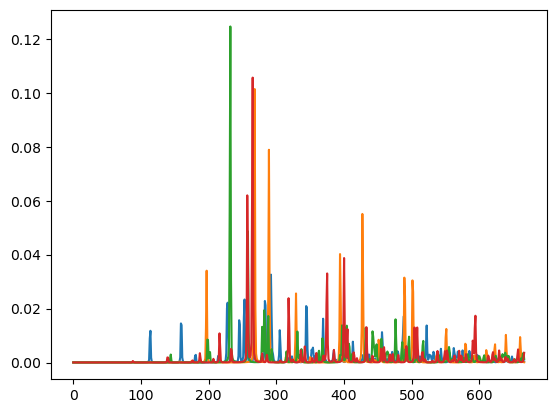

Loading integrated diffraction data
(181, 362, 667)


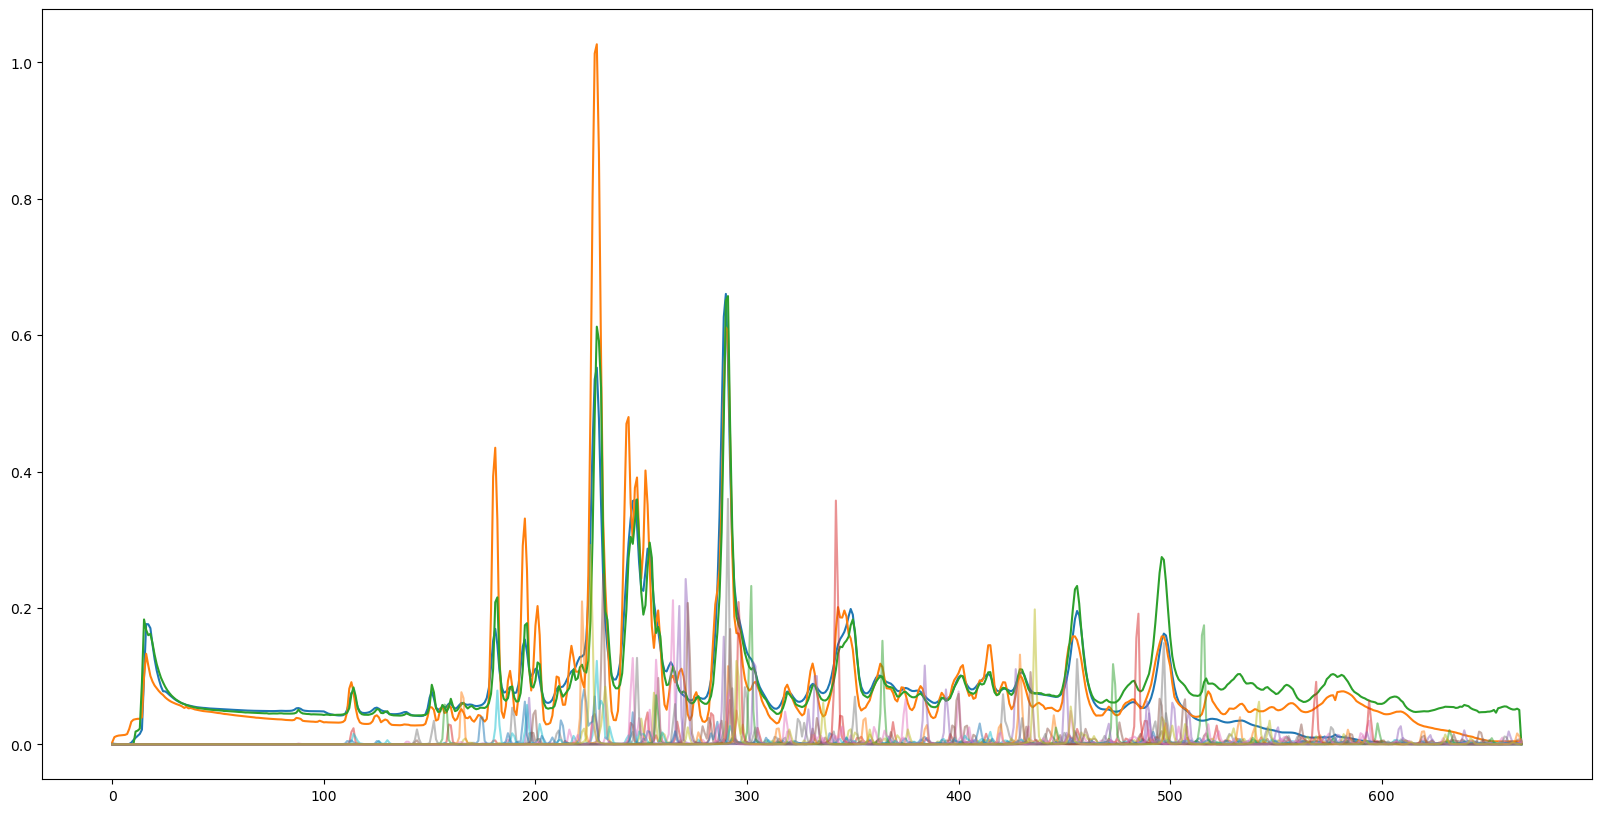

In [275]:
def load_xy_files(base_folder):
    data_dict = {}

    for root, _, files in os.walk(base_folder):
        for file in files:
            if file.endswith('.xy'):
                filepath = os.path.join(root, file)

                # Extract key: everything between first underscore and '.xy'
                try:
                    first_underscore = file.index('_') + 1
                    last_dot = file.rindex('.xy')
                    key = file[first_underscore:last_dot]
                except ValueError:
                    continue  # skip files not matching pattern

                # Load only the first two columns
                data = np.loadtxt(filepath, usecols=(0, 1), max_rows = 1740)
                data_dict[key] = data

    return data_dict


def add_convolved_columns(data_dict, stds):
    new_dict = {}
    for key, arr in data_dict.items():
        base_x = arr[:, 0]
        base_y = arr[:, 1]

        # Apply gaussian filters with each std in stds
        smoothed_columns = [gaussian_filter1d(base_y, sigma=s) for s in stds]

        # Stack: x, y, smoothed1, smoothed2, ..., smoothed_{K-2}
        new_arr = np.column_stack([base_x, base_y] + smoothed_columns)
        new_dict[key] = new_arr

    return new_dict


def interpolate_dict_values(data_dict, k, n_points=667):
    results = []
    keys = []
    for key in data_dict:
        x = data_dict[key][:, 0]
        y = data_dict[key][:, k]
        x_new = np.linspace(0, x[-1], n_points)
        y_new = np.interp(x_new, x, y)
        y_new = y_new / y_new.sum()
        results.append(y_new.astype(np.float32))
        keys.append(key)
    return results, keys


spec_dictionary = load_xy_files('/dtu-compute/msaca/sliceA_diffraction/cif-files_and_theoretical_pd_spectra/PowderDiff_shortlist')
spec_dictionary = add_convolved_columns(spec_dictionary, [1])
print(spec_dictionary['Ca5(PO4)3Cl_chlorapatite'][-1,0])
print(spec_dictionary['Ca5(PO4)3Cl_chlorapatite'][0,0])
spec, keys = interpolate_dict_values(spec_dictionary, 2, n_points=667)
for i in range(len(spec)-12):
    plt.plot(spec[i])

plt.show()


print('Loading integrated diffraction data')
with h5py.File('/dtu-compute/msaca/sliceA_diffraction/xrd_ct_integrated/scan-0341_pilatus_integrated.h5', 'r') as file:
    d_old = file['entry/data1d/I'][:]
    d_old = d_old[:,::3].reshape(181, 362, 667)
    print(d_old.shape)


plt.figure(figsize=(20,10))
plt.plot(np.mean(datap*2,axis=(0,1)))
plt.plot(np.mean(dataq*15,axis=(0,1)))
plt.plot(np.mean(d_old/10,axis=(0,1)))
for i in range(len(spec)):
    plt.plot(spec[i]*2, alpha=0.5)




In [218]:


L = len(spec[0])
def wdot(a, b, W):  # weighted inner product
    return (W * a * b).sum()

def gram_schmidt_weighted(S, W):
    L, K = S.shape
    Q = np.zeros_like(S, dtype=float)
    for k in range(K):
        v = S[:, k].copy()
        for j in range(k):
            proj = wdot(Q[:, j], v, W) * Q[:, j]  # since Q is W-orthonormal
            v = v - proj
        # normalize
        norm = np.sqrt(wdot(v, v, W))
        Q[:, k] = v / (norm + 1e-15)
    return Q  # columns are W-orthonormal

# usage
S = np.column_stack([spec[0], spec[1], spec[2], spec[3]])  # shape (L,4)
W = np.ones(L)  # or 1/variance, or integration weights
Q = gram_schmidt_weighted(S, W)  # new uncorrelated basis

spec2 = [Q[:, i].astype(np.float32) for i in range(Q.shape[1])]


def lowdin_orthonormalize(S, W):
    SW = S * np.sqrt(W[:, None])        # weight rows
    G = SW.T @ SW                       # Gram
    eigvals, eigvecs = np.linalg.eigh(G)
    Gm12 = eigvecs @ np.diag(1.0/np.sqrt(eigvals + 1e-15)) @ eigvecs.T
    Q = S @ Gm12                        # columns are W-orthonormal
    return Q


# usage
S = np.column_stack(spec)  # shape (L,4)
W = np.ones(L)  # or 1/variance, or integration weights
Q = lowdin_orthonormalize(S, W)  # new uncorrelated basis

spec3 = [Q[:, i].astype(np.float32) for i in range(Q.shape[1])]



In [279]:


A1 = np.arange(339, 449+1, 2)
A2 = np.arange(455, 471+1, 2)
A3 = np.arange(475, 487+1, 2)
A = np.concatenate([A1,A2,A3])
# A = A1
data_path = '/dtu-compute/msaca/sliceA_diffraction/powder-crystal/integrated-####.h5'
data_files = ma.generate_paths(data_path, A)
data_att_path = '/dtu-compute/msaca/sliceA_diffraction/powder-crystal/scan-####_xspress3-dtc-2d.h5'
data_att_files = ma.generate_paths(data_att_path, A)
output_path = '/dtu-compute/msaca/sliceA_diffraction/powder-crystal/recons2-DA-####.h5'
output_files = ma.generate_paths(output_path, A)

def inner_product(data, spec):
    results = []
    for s in spec:
        s_norm = s / s.sum()
        results.append((data * s_norm).sum(axis=-1))
    return np.stack(results)

c0, c1 = 0, 667
y0,y1 = 130, 230
alpha_dc_ = 0


N_labels = 20

recon = []

q_key = 'crystal_q-80'
p_key = 'powder_q-80'

i_slice = 20

print('Loading absorption data for slice', i_slice)
with h5py.File(data_att_files[i_slice], 'r') as file:
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    dtc= file['entry/instrument/xspress3']
    data_att = dtc['window_counts'][:][:,0].reshape(181,362).astype(np.float32)

print('Loading integrated diffraction data')
with h5py.File(data_files[i_slice], 'r') as file:
    datasetq = file[q_key][:]
    datasetq = np.sum(datasetq,axis=2)

    datasetp = file[p_key][:]

print('Loaded data for slice ', i_slice)

dataq = np.transpose(datasetq/data_att[:,:,None],[0,1,2])[:][c0:c1].astype(np.float32)
datap = np.transpose(datasetp/data_att[:,:,None],[0,1,2])[:][c0:c1].astype(np.float32)
nc, na, nx = np.shape(dataq)

ip_p = inner_product(datap/(datap.sum(axis=(0,1,2), keepdims=True)+0.00001),spec3)
ip_q = inner_product(dataq/(dataq.sum(axis=(0,1,2),keepdims=True)+0.00001),spec3)

dat_p = ip_p/(np.sum(ip_p,axis=(2), keepdims=True)+0.0001)
dat_q = ip_q/(np.sum(ip_p,axis=(2), keepdims=True)+0.0001)
angles = np.arange(0,181)


rec_p = cgls1(dat_p, angles, 0, alpha=0, alpha_dx = 0, alpha_dy = 0, niter = 30).transpose([0, 1, 2])[:,130:-130]
rec_q, t2 = pdhg3(dat_q,angles = angles, niter = 30, alpha_tv = 0.00000002, delta=0.00001, step_scaler = 1)
rec_q = rec_q.transpose([0, 1, 2])[:,130:-130]

Loading absorption data for slice 20


Loading integrated diffraction data
Loaded data for slice  20


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

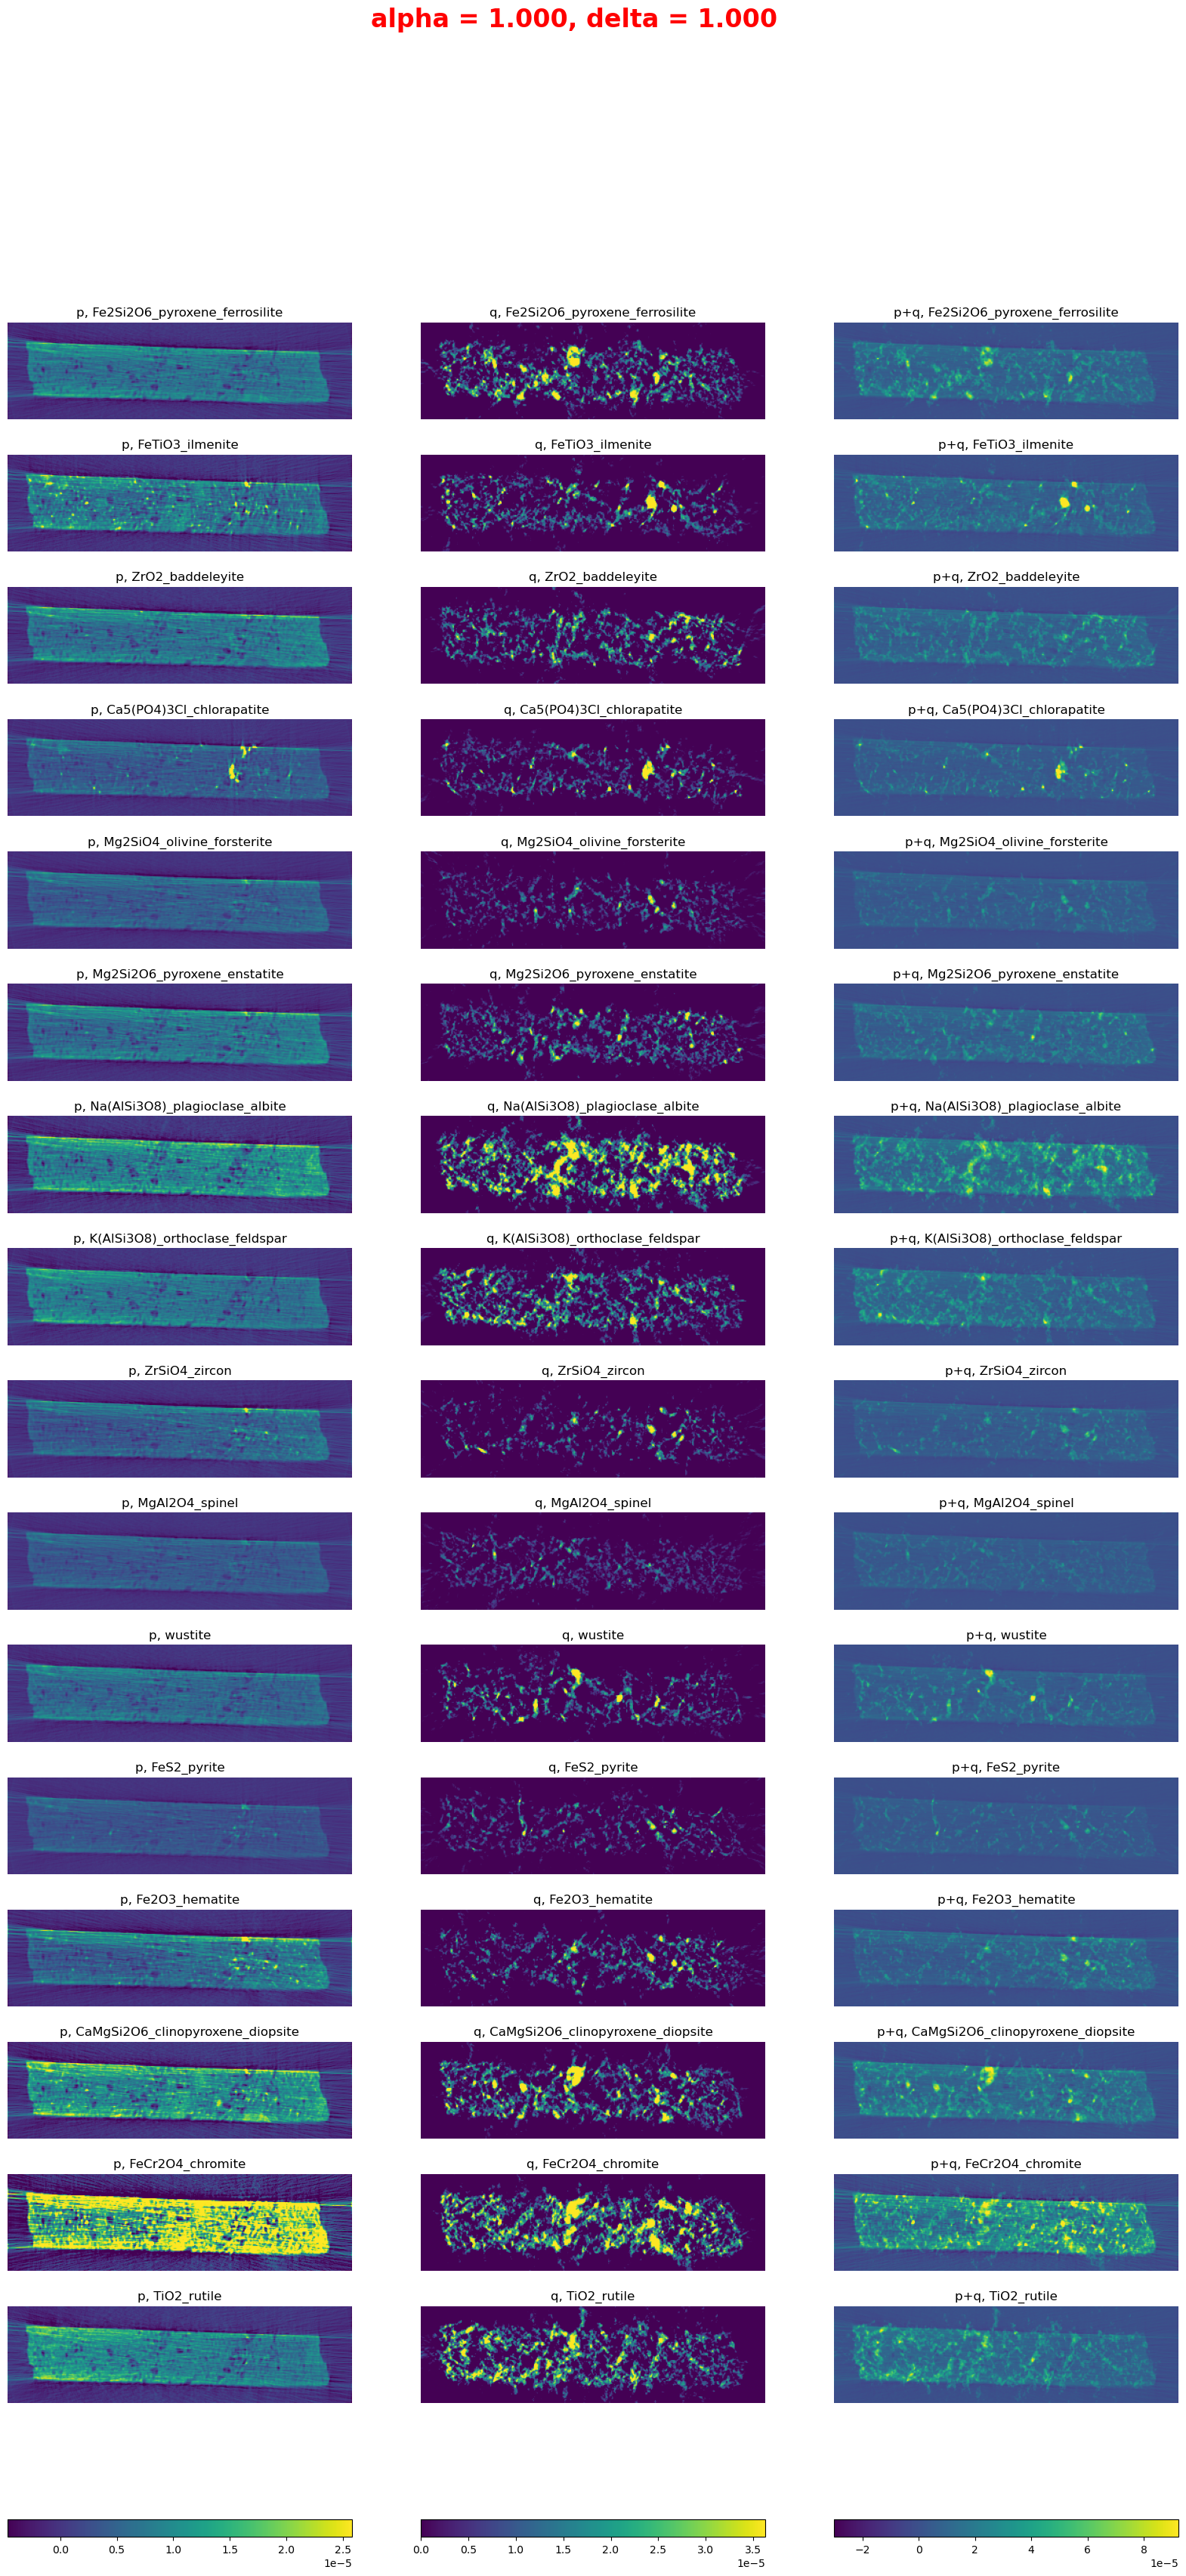

In [282]:
alpha=1.0
delta=1.0
n = len(spec)

vmin_p, vmax_p = np.quantile(rec_p, [0.01, 0.99])
vmin_q, vmax_q = np.quantile(rec_q, [0.01, 0.99])
vmin_sum, vmax_sum = np.quantile(np.array(rec_p) + np.array(rec_q), [0.000001, 0.999])

fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(20, 2.5 * n))

for i in range(n):
    key = keys[i]
    im0 = axes[i, 0].imshow(rec_p[i], vmin=vmin_p, vmax=vmax_p)
    axes[i, 0].set_title(f"p, {key}")
    axes[i, 0].axis("off")

    im1 = axes[i, 1].imshow(rec_q[i], vmin=vmin_q, vmax=vmax_q)
    axes[i, 1].set_title(f"q, {key}")
    axes[i, 1].axis("off")

    im2 = axes[i, 2].imshow(rec_p[i] + rec_q[i], vmin=vmin_sum, vmax=vmax_sum)
    axes[i, 2].set_title(f"p+q, {key}")
    axes[i, 2].axis("off")

# Add horizontal colorbars below last row of each column
cbar0 = fig.colorbar(im0, ax=axes[:, 0], orientation="horizontal", fraction=0.05, pad=0.05)
cbar1 = fig.colorbar(im1, ax=axes[:, 1], orientation="horizontal", fraction=0.05, pad=0.05)
cbar2 = fig.colorbar(im2, ax=axes[:, 2], orientation="horizontal", fraction=0.05, pad=0.05)
fig.suptitle(f"alpha = {alpha:.3f}, delta = {delta:.3f}",
             fontsize=24, color="red", weight="bold")

#plt.tight_layout()
plt.show()

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:

deltas =np.logspace(np.log10(0.00003), np.log10(0.1), 10)
alpha_tvs = np.logspace(np.log10(0.0001), np.log10(1), 10)


for k in range(len(alpha_tvs)):
    for j in range(len(deltas)):
        alpha = alpha_tvs[k]
        delta = deltas[j]
        rec_p, t2 = pdhg3((100*dat_p).astype(np.float32),angles = angles, niter = 70, alpha_tv = alpha, delta=delta, step_scaler = 1)
        rec_q, t2 = pdhg3((100*dat_q).astype(np.float32),angles = angles, niter = 100, alpha_tv = alpha, delta=delta, step_scaler = 1)
        rec_p = rec_p.transpose([0, 1, 2])[:,130:-130]
        rec_q = rec_q.transpose([0, 1, 2])[:,130:-130]

        n = len(spec)

        vmin_p, vmax_p = np.quantile(rec_p, [0.01, 0.99])
        vmin_q, vmax_q = np.quantile(rec_q, [0.01, 0.99])
        vmin_sum, vmax_sum = np.quantile(np.array(rec_p) + np.array(rec_q), [0.000001, 0.999])

        fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(20, 2.5 * n))

        for i in range(n):
            key = keys[i]
            im0 = axes[i, 0].imshow(rec_p[i], vmin=vmin_p, vmax=vmax_p)
            axes[i, 0].set_title(f"p, {key}")
            axes[i, 0].axis("off")

            im1 = axes[i, 1].imshow(rec_q[i], vmin=vmin_q, vmax=vmax_q)
            axes[i, 1].set_title(f"q, {key}")
            axes[i, 1].axis("off")

            im2 = axes[i, 2].imshow(rec_p[i] + rec_q[i], vmin=vmin_sum, vmax=vmax_sum)
            axes[i, 2].set_title(f"p+q, {key}")
            axes[i, 2].axis("off")

        # Add horizontal colorbars below last row of each column
        cbar0 = fig.colorbar(im0, ax=axes[:, 0], orientation="horizontal", fraction=0.05, pad=0.05)
        cbar1 = fig.colorbar(im1, ax=axes[:, 1], orientation="horizontal", fraction=0.05, pad=0.05)
        cbar2 = fig.colorbar(im2, ax=axes[:, 2], orientation="horizontal", fraction=0.05, pad=0.05)
        fig.suptitle(f"alpha = {alpha:.5f}, delta = {delta:.5f}",
             fontsize=24, color="red", weight="bold")

        #plt.tight_layout()
        outfile = '/dtu-compute/msaca/sliceA_diffraction/figures/2025_09_03_experiment/' + f"reconstruction_alpha{alpha:.5f}_delta{delta:.5f}.png"
        fig.savefig(outfile, dpi=300, bbox_inches="tight")
        plt.close('all')


  0%|          | 0/70 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/70 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/70 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/70 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/70 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:

for i in range(len(data_files)):


    print('Loading absorption data for slice', i)
    with h5py.File(data_att_files[i], 'r') as file:
        # Access a dataset or group (replace 'your_dataset' with the correct key)
        dtc= file['entry/instrument/xspress3']
        data_att = dtc['window_counts'][:][:,0].reshape(181,362).astype(np.float32)



    print('Loading integrated diffraction data')
    with h5py.File(data_files[i], 'r') as file:
        datasetq = file[q_key][:]
        datasetq = np.sum(datasetq,axis=2)

        datasetp = file[p_key][:]

    print('Loaded data for slice ', i)

    dataq = np.transpose(datasetq/200,[2,0,1])[:][c0:c1].astype(np.float32)
    datap = np.transpose(datasetp/200,[2,0,1])[:][c0:c1].astype(np.float32)
    nc, na, nx = np.shape(dataq)

    print('Ruuning cgls on crystal data')
    reconq = cgls1(dataq, data_att, alpha_dc_*0.2)
    print('Running cgls on powder data')
    reconp = cgls1(datap, data_att, alpha_dc_)

    angles = np.arange(0,181,1)
    device = 'gpu'


    d_channels = []
    intersector_recon = np.zeros((nc,N_labels, y1-y0,nx))
    print('Running crystal line intersection analysis')